## Section 11 — TensorBoard

View live training progress. Logs include loss, macro F1, per-label AUC-ROC, and learning rate per epoch.


In [16]:
%load_ext tensorboard
%tensorboard --logdir {CFG.TENSORBOARD_DIR}


Reusing TensorBoard on port 6007 (pid 183917), started 2:06:26 ago. (Use '!kill 183917' to kill it.)

## Section 12 — Training Curves

Six plots summarising the full training run:

1. **Focal Loss** — training and validation loss. Both should decrease; a growing gap indicates overfitting.
2. **Macro F1** — primary metric averaged across all three labels.
3. **Per-label AUC-ROC** — separability per condition. Above 0.5 = better than random, 1.0 = perfect.
4. **Overfitting gap** — training F1 minus validation F1. Values above zero indicate the model fits training data better than unseen data.
5. **Learning rate schedule** — cosine decay with warmup restarts at each unfreezing event.
6. **Trainable parameters** — three-step increase as the backbone is progressively unfrozen.

Vertical lines mark the two unfreezing events and the minimum epoch threshold.


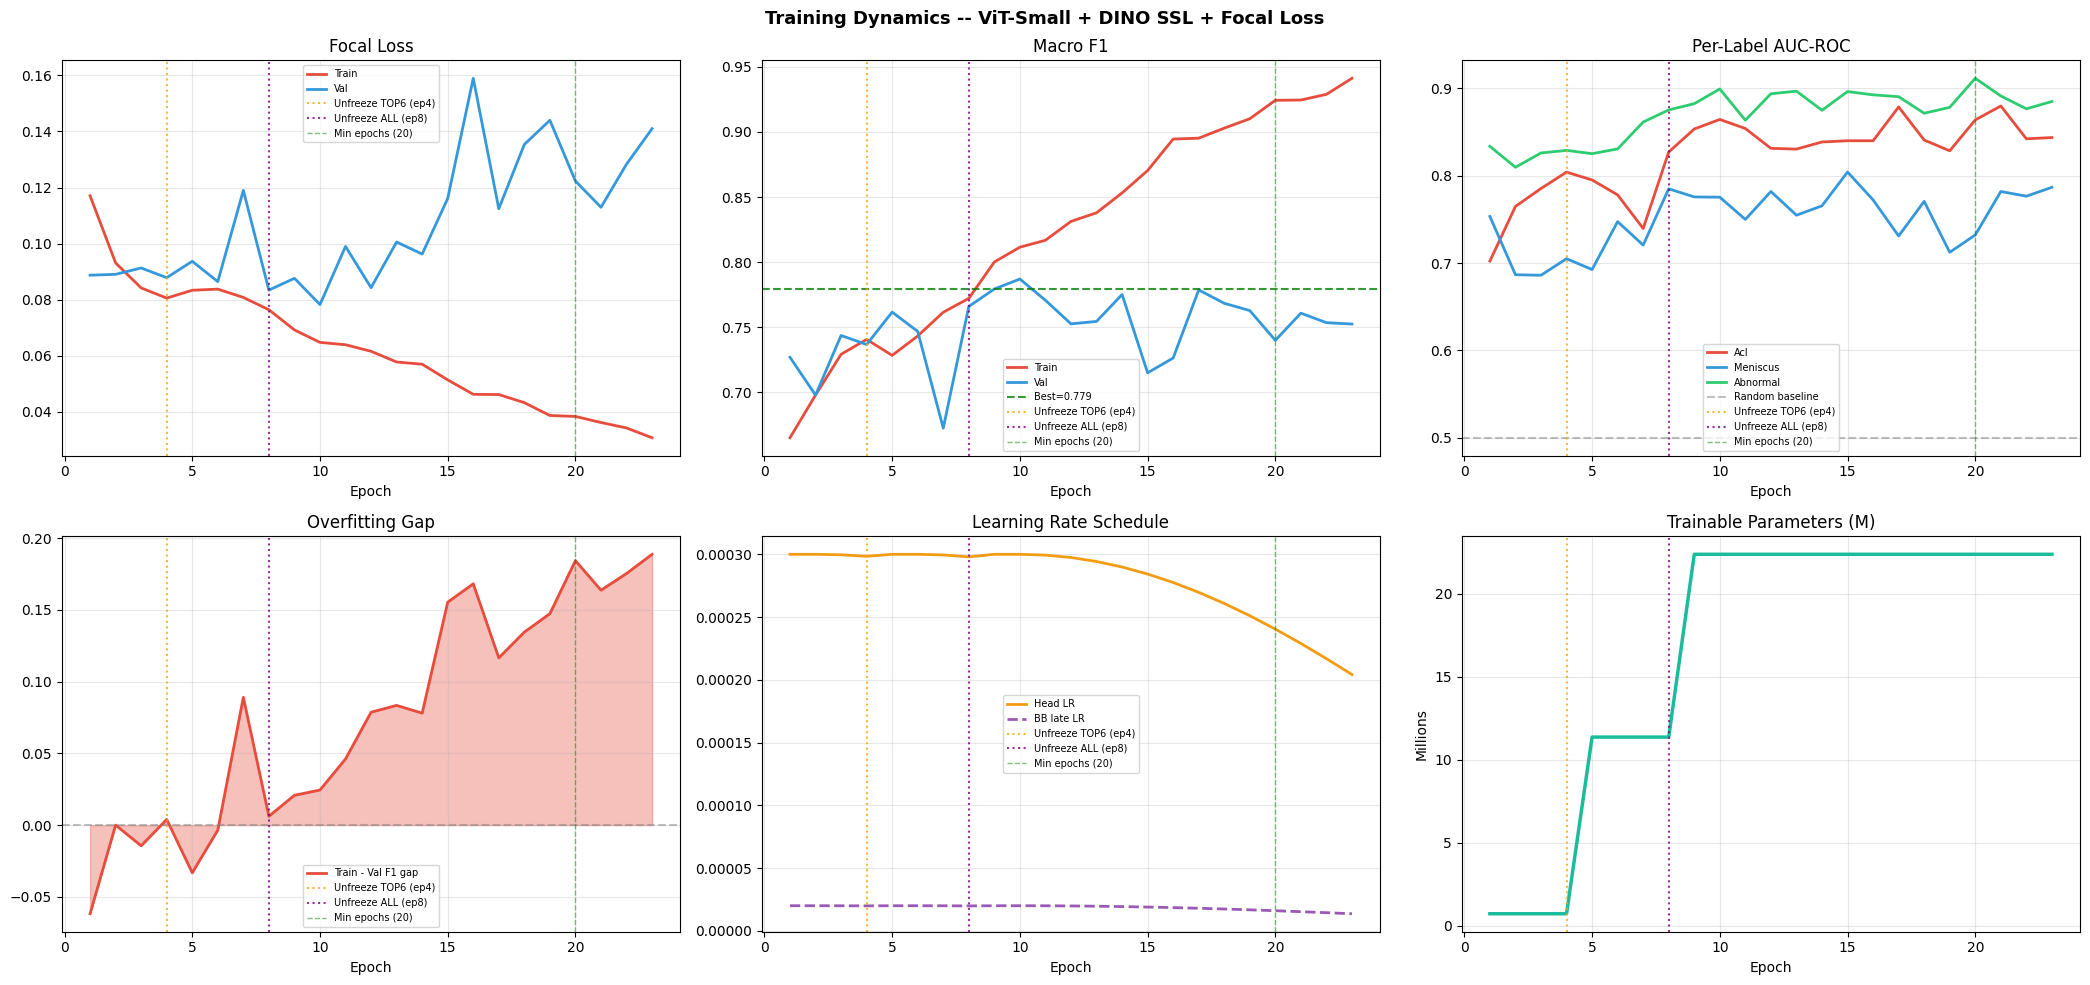

In [17]:
ep = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(2, 3, figsize=(21, 10))
fig.suptitle("Training Dynamics -- ViT-Small + DINO SSL + Focal Loss", fontsize=13, fontweight="bold")

def add_stages(ax):
    ax.axvline(CFG.UNFREEZE_PARTIAL_EP, color="orange", linestyle=":", alpha=0.8, lw=1.5,
               label=f"Unfreeze TOP{CFG.N_BLOCKS_PARTIAL} (ep{CFG.UNFREEZE_PARTIAL_EP})")
    ax.axvline(CFG.UNFREEZE_FULL_EP,    color="purple", linestyle=":", alpha=0.8, lw=1.5,
               label=f"Unfreeze ALL (ep{CFG.UNFREEZE_FULL_EP})")
    ax.axvline(CFG.MIN_EPOCHS,          color="green",  linestyle="--", alpha=0.5, lw=1,
               label=f"Min epochs ({CFG.MIN_EPOCHS})")

axes[0,0].plot(ep, history["train_loss"], label="Train", color="#E74C3C", lw=2)
axes[0,0].plot(ep, history["val_loss"],   label="Val",   color="#3498DB", lw=2)
add_stages(axes[0,0])
axes[0,0].set_title("Focal Loss"); axes[0,0].legend(fontsize=7); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep, history["train_f1"], label="Train", color="#E74C3C", lw=2)
axes[0,1].plot(ep, history["val_f1"],   label="Val",   color="#3498DB", lw=2)
axes[0,1].axhline(best_val_f1, color="green", linestyle="--", alpha=0.8, label=f"Best={best_val_f1:.3f}")
add_stages(axes[0,1])
axes[0,1].set_title("Macro F1"); axes[0,1].legend(fontsize=7); axes[0,1].grid(alpha=0.3)

for name, col in zip(CFG.LABEL_NAMES, ["#E74C3C","#3498DB","#2ECC71"]):
    axes[0,2].plot(ep, history[f"auc_{name}"], label=name.capitalize(), color=col, lw=2)
axes[0,2].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
add_stages(axes[0,2])
axes[0,2].set_title("Per-Label AUC-ROC"); axes[0,2].legend(fontsize=7); axes[0,2].grid(alpha=0.3)

gap = [t - v for t, v in zip(history["train_f1"], history["val_f1"])]
axes[1,0].fill_between(ep, 0, gap, alpha=0.35, color="#E74C3C")
axes[1,0].plot(ep, gap, color="#E74C3C", lw=2, label="Train - Val F1 gap")
axes[1,0].axhline(0, color="gray", linestyle="--", alpha=0.5)
add_stages(axes[1,0])
axes[1,0].set_title("Overfitting Gap"); axes[1,0].legend(fontsize=7); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ep, history["lr_head"],    label="Head LR",    color="#F39C12", lw=2)
axes[1,1].plot(ep, history["lr_bb_late"], label="BB late LR", color="#9B59B6", lw=2, linestyle="--")
add_stages(axes[1,1])
axes[1,1].set_title("Learning Rate Schedule"); axes[1,1].legend(fontsize=7); axes[1,1].grid(alpha=0.3)

axes[1,2].plot(ep, [p/1e6 for p in history["trainable"]], color="#1ABC9C", lw=2.5)
axes[1,2].axvline(CFG.UNFREEZE_PARTIAL_EP, color="orange", linestyle=":", alpha=0.8)
axes[1,2].axvline(CFG.UNFREEZE_FULL_EP,    color="purple", linestyle=":", alpha=0.8)
axes[1,2].set_title("Trainable Parameters (M)"); axes[1,2].set_ylabel("Millions")
axes[1,2].grid(alpha=0.3)

for ax in axes.flat: ax.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(CFG.OUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 13 — Evaluation

Load the best checkpoint and evaluate on the 120-scan validation set.

**Metrics computed per condition:**
- **Accuracy** — fraction of correct binary predictions at threshold 0.5
- **Sensitivity (Recall)** — fraction of actual positives the model correctly detects. Clinically important: missing a real tear is worse than a false alarm.
- **Specificity** — fraction of actual negatives correctly identified.
- **Precision** — fraction of positive predictions that are actually correct.
- **F1-Score** — harmonic mean of precision and recall. More meaningful than accuracy for imbalanced classes.
- **AUC-ROC** — area under the ROC curve. Threshold-independent. 0.5 = random, 1.0 = perfect.


In [18]:
ckpt = torch.load(CFG.CHECKPOINT_PATH, map_location=CFG.DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.unfreeze_all()
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  val_F1={ckpt['val_f1']:.4f}")

all_probs, all_preds, all_targets = [], [], []

with torch.no_grad():
    for sag, cor, axi, targets, _ in valid_loader:
        sag, cor, axi = sag.to(CFG.DEVICE), cor.to(CFG.DEVICE), axi.to(CFG.DEVICE)
        logits = model(sag, cor, axi)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_preds.append((probs >= 0.5).astype(int))
        all_targets.append(targets.numpy())

y_probs = np.vstack(all_probs)
y_preds = np.vstack(all_preds)
y_true  = np.vstack(all_targets)

for i, name in enumerate(CFG.LABEL_NAMES):
    print(f"\n--- {name.upper()} ---")
    print(classification_report(y_true[:, i], y_preds[:, i],
          target_names=["Negative", "Positive"], digits=4))


Loaded checkpoint from epoch 11  val_F1=0.7708

--- ACL ---
              precision    recall  f1-score   support

    Negative     0.9444    0.5152    0.6667        66
    Positive     0.6190    0.9630    0.7536        54

    accuracy                         0.7167       120
   macro avg     0.7817    0.7391    0.7101       120
weighted avg     0.7980    0.7167    0.7058       120


--- MENISCUS ---
              precision    recall  f1-score   support

    Negative     0.8333    0.2941    0.4348        68
    Positive     0.5000    0.9231    0.6486        52

    accuracy                         0.5667       120
   macro avg     0.6667    0.6086    0.5417       120
weighted avg     0.6889    0.5667    0.5275       120


--- ABNORMAL ---
              precision    recall  f1-score   support

    Negative     0.7333    0.4400    0.5500        25
    Positive     0.8667    0.9579    0.9100        95

    accuracy                         0.8500       120
   macro avg     0.8000    0.698

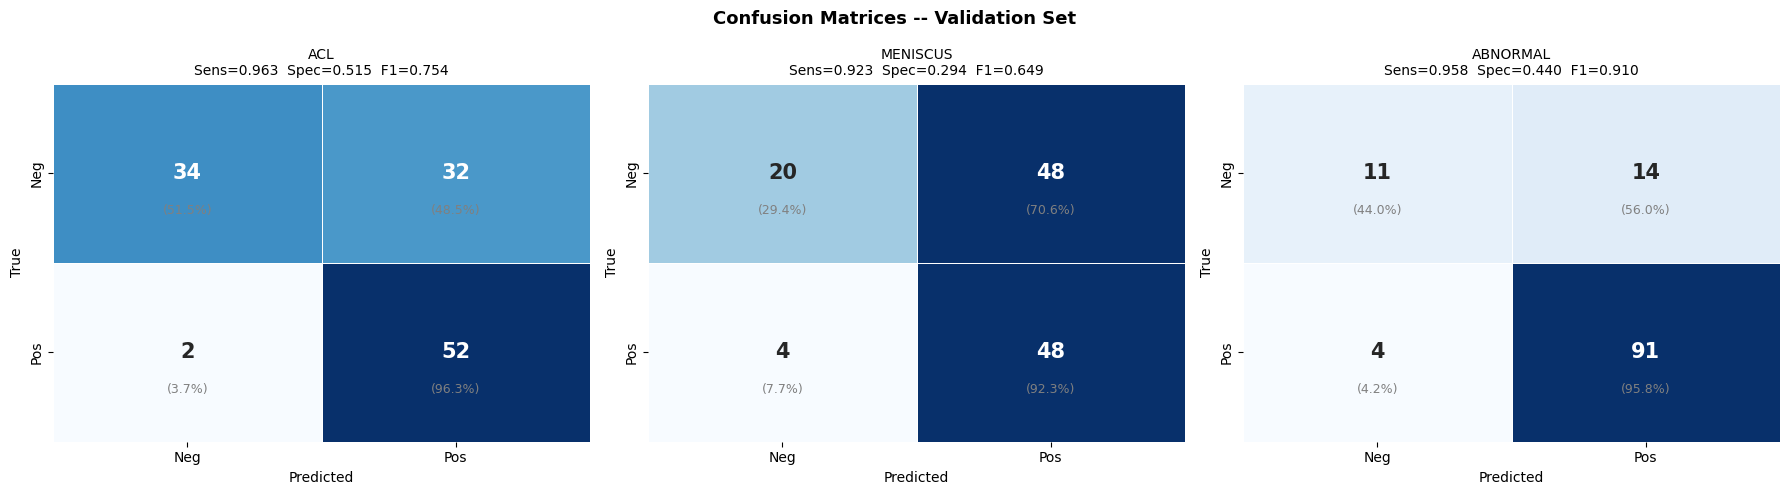

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices -- Validation Set", fontsize=13, fontweight="bold")

for i, (ax, name) in enumerate(zip(axes, CFG.LABEL_NAMES)):
    cm_raw  = confusion_matrix(y_true[:, i], y_preds[:, i])
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)
    sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"],
                linewidths=0.5, cbar=False, annot_kws={"size":15, "weight":"bold"})
    for (r, c), v in np.ndenumerate(cm_raw):
        ax.text(c+0.5, r+0.73, f"({100*cm_norm[r,c]:.1f}%)",
                ha="center", fontsize=9, color="gray")
    tn, fp, fn, tp = cm_raw.ravel()
    sens = tp/(tp+fn) if (tp+fn) > 0 else 0
    spec = tn/(tn+fp) if (tn+fp) > 0 else 0
    f1_i = f1_score(y_true[:,i], y_preds[:,i], zero_division=0)
    ax.set_title(f"{name.upper()}\nSens={sens:.3f}  Spec={spec:.3f}  F1={f1_i:.3f}", fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(CFG.OUT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


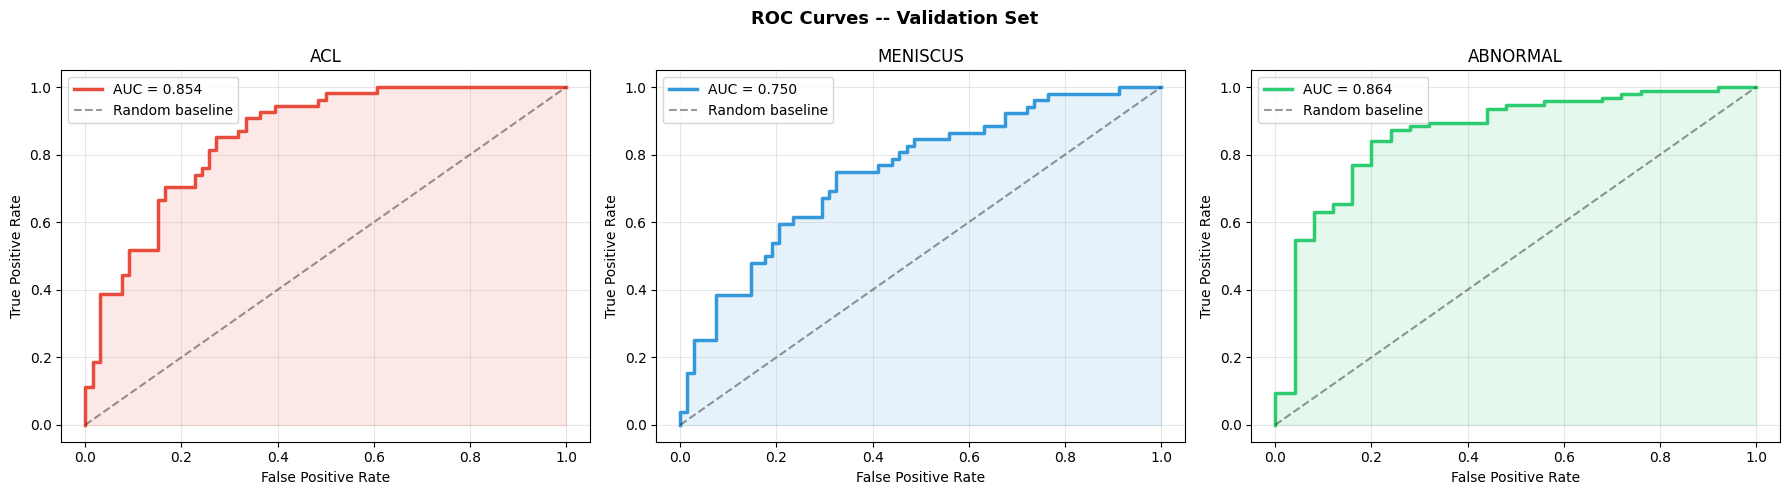

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ROC Curves -- Validation Set", fontsize=13, fontweight="bold")

for i, (ax, name, col) in enumerate(zip(axes, CFG.LABEL_NAMES, ["#E74C3C","#3498DB","#2ECC71"])):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
    auc_val = roc_auc_score(y_true[:, i], y_probs[:, i])
    ax.plot(fpr, tpr, color=col, lw=2.5, label=f"AUC = {auc_val:.3f}")
    ax.fill_between(fpr, tpr, alpha=0.12, color=col)
    ax.plot([0,1],[0,1], "k--", alpha=0.4, label="Random baseline")
    ax.set_title(name.upper()); ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CFG.OUT_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
